In [1]:
# Funciones para el modelo Approximate Bayesian Computation (ABC-SMC)
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from multiprocessing import get_context
from scipy.special import logsumexp
from scipy.special import gamma as gamma_function
from scipy.spatial.distance import pdist, squareform
from scipy.stats import gamma, norm, multivariate_normal
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler

# Incluir columnas de fenómeno ENSO (El Niño, La Niña, Neutral)
def importar_ENSO():
    url = "https://psl.noaa.gov/data/correlation/oni.data"
    
    df = pd.read_csv(
        url,
        sep=r"\s+",
        skiprows=1,
        engine="python",
        on_bad_lines="skip"
    )

    df = df[pd.to_numeric(df.iloc[:, 0], errors="coerce").notna()]

    df.columns = [
        "year","DJF","JFM","FMA","MAM","AMJ","MJJ",
        "JJA","JAS","ASO","SON","OND","NDJ"
    ]

    df = df.melt(
        id_vars="year",
        var_name="season",
        value_name="ONI"
    )

    df["ONI"] = pd.to_numeric(df["ONI"], errors="coerce")
    df = df.dropna(subset=["ONI"])
    df = df[df["ONI"] != -99.90]

    mapa_mes = {
        "DJF": 1, "JFM": 2, "FMA": 3, "MAM": 4,
        "AMJ": 5, "MJJ": 6, "JJA": 7, "JAS": 8,
        "ASO": 9, "SON": 10, "OND": 11, "NDJ": 12
    }

    df["month"] = df["season"].map(mapa_mes)
    df["year"] = df["year"].astype(int)

    df = df.sort_values(["year", "month"]).reset_index(drop=True)

    # Identificar ONI mayores o menores a +- 0.5
    df["signal"] = np.where(df["ONI"] >= 0.5, 1, np.where(df["ONI"] <= -0.5, -1, 0))
    # Identificar rachas de señales consecutivas iguales
    df["grupo"] = (df["signal"] != df["signal"].shift()).cumsum()

    # Contar longitud de cada racha
    tamaños = df.groupby("grupo")["signal"].transform("size")

    # Condiciones para fenómeno Niño o Niña: Cinco o más períodos sobrelapados con ONI >= 0.5 o ONI <= -0.5 
    def clasificar(row):
        if row["signal"] == 1 and tamaños[row.name] >= 5:
            return "El Niño"
        elif row["signal"] == -1 and tamaños[row.name] >= 5:
            return "La Niña"
        else:
            return "Neutral"

    df["ENSO"] = df.apply(clasificar, axis=1)
    df = df.drop(columns=["signal", "grupo"])

    return df

# Estacionalidad mensual mediante serie de Fourier
def fourier_mensual(mes):
    fourier = np.column_stack([
        np.sin(2 * np.pi * mes / 12).round(3),
        np.cos(2 * np.pi * mes / 12).round(3),
        np.sin(4 * np.pi * mes / 12).round(3),
        np.cos(4 * np.pi * mes / 12).round(3)
    ])
    fourier_df = pd.DataFrame(fourier, columns=['sin_1', 'cos_1', 'sin_2', 'cos_2'])
    return fourier_df

# Métrica de error cuatrático medio (MSE)
def mse(X, Y):
    return np.mean((X - Y) ** 2)

# Métrica de error medio absoluto (MAE)
def mae(X, Y):
    return np.mean(np.abs(X - Y))

# Métrica de error cuadrático cuantílico promedio (ECCP)
def error_cuadratico_cuantilico(X, Y):
    c = 10 # Número de cuantiles en cada extremo
    cuantiles = np.concatenate([np.arange(1, c + 1),np.arange(100 - c, 100)]) / 100

    q_X = np.quantile(X, cuantiles, axis=0)
    q_Y = np.quantile(Y, cuantiles, axis=0)

    eccp = mse(q_X, q_Y)
    return eccp

# Métrica de error absoluto cuantílico promedio (EACP)
def error_absoluto_cuantilico(X, Y):
    c = 10 # Número de cuantiles en cada extremo
    cuantiles = np.concatenate([np.arange(1, c + 1),np.arange(100 - c, 100)]) / 100

    q_X = np.quantile(X, cuantiles, axis=0)
    q_Y = np.quantile(Y, cuantiles, axis=0)

    eacp = mae(q_X, q_Y)
    return eacp

# Preparar datos para una región específica, incluyendo precipitación mensual y covariables espaciales
def preparar_datos_region(datos, region):
    # Filtrar por región
    datos_region = datos.loc[datos['region'] == region].copy()

    datos_region['lon'] = datos_region['lon'].round(3)
    datos_region['lat'] = datos_region['lat'].round(3)

    # Preparar dataframe con datos mensuales de precipitación y covariables espaciales (latitud, longitud, elevación)
    datos_region['date'] = pd.to_datetime(datos_region['date'])
    datos_region = datos_region.sort_values('date').reset_index(drop=True)
    datos_region['year_month'] = datos_region['date'].dt.to_period('M')
    datos_region = (
        datos_region.
        groupby(['lat', 'lon', 'year_month']).
        agg({
            'chirps': 'sum',
            'elevation': 'first',
            'date': 'first'}).
        reset_index().
        copy()
    )
    # Columna con número de mes (1 - 12)
    datos_region["month"] = datos_region["date"].dt.month
    # Columna con número de año
    datos_region["year"] = datos_region["date"].dt.year

    # Agregar términos de la serie de Fourier para capturar estacionalidad mensual
    datos_region = pd.concat([datos_region, fourier_mensual(datos_region['month'])], axis=1)

    # Importar datos de NOAA (ONI index)
    enso_noaa = importar_ENSO()[["year", "month", "ENSO"]]

    # Incluir ENSO
    datos_region = datos_region.merge(enso_noaa, on=["year", "month"], how="left")
    datos_region['ENSO'] = pd.Categorical(datos_region['ENSO'], categories=['Neutral', 'El Niño', 'La Niña'], ordered=False)

    return datos_region

# Dividir los datos en conjuntos de entrenamiento y prueba
def dividir_train_test(datos, ubic, nsites, fecha_corte, frac=0.75, seed=1234):
    # Seleccionar aleatoriamente un subconjunto de ubicaciones para entrenamiento    
    n_ubic_train = int(frac * nsites)
    ubic_train = ubic.sample(n=n_ubic_train, random_state=seed)
    
    # Crear máscaras para filtrado
    mask_time_train = datos['date'] <= fecha_corte
    indice_ubicaciones = pd.MultiIndex.from_frame(datos[['lon', 'lat']])
    indice_training = pd.MultiIndex.from_frame(ubic_train[['lon', 'lat']])
    mask_ubic_train = indice_ubicaciones.isin(indice_training)

    # Separar datos de entrenamiento y prueba
    datos_train = datos[mask_time_train & mask_ubic_train]
    datos_test = datos[~(mask_time_train & mask_ubic_train)]

    # Cantidad de meses (filas) para entrenamiento por sitio
    m_train = int(len(datos_train)/n_ubic_train)

    return datos_train, datos_test, m_train

# Obtener conjunto de ubicaciones únicas, número de sitios y matriz de distancias entre ubicaciones
def parametros_ubicaciones(datos):
    # Combinaciones únicas de latitud y longitud
    ubic = (
        datos[['lon','lat','elevation']]
        .drop_duplicates()
        .sort_values(['lat','lon'], ascending=[False,True])
        .reset_index(drop=True)
    )
    # Número de ubicaciones únicas
    nsites = ubic.shape[0]

    # Matriz de distancias entre ubicaciones
    dist_mat = squareform(pdist(ubic[['lon','lat']])) # Dimensiones: nsites x nsites

    return ubic, nsites, dist_mat

# Constructor de objetos para calcular términos polinomiales y estandarización de datos
def preprocesamiento_escalar_datos(train):
    poly = PolynomialFeatures(degree=2, include_bias=False)
    scaler = StandardScaler()

    # Constructor de términos polinomiales
    X_poly = poly.fit_transform(train[columnas_polinomicas])
    poly_cols = poly.get_feature_names_out(columnas_polinomicas)
    X_poly = pd.DataFrame(X_poly, columns=poly_cols, index=train.index)

    # Constructor de estandarización
    scaler.fit(X_poly)

    return poly, scaler

columnas_polinomicas = ['lat', 'lon']
columnas_no_polinomicas = ['elevation', 'sin_1', 'cos_1', 'sin_2', 'cos_2', 'ENSO', 'month']
# Columnas seleccionadas para la matriz de diseño
columnas_matriz_diseno = ['lat', 'lon', 'sin_1', 'cos_1', 'sin_2', 'cos_2']

# Construir matriz de diseño
def procesamiento_matriz_diseno(datos, poly, scaler):
    # Terminos polinomiales de latitud y longitud
    X_poly = poly.transform(datos[columnas_polinomicas])
    poly_cols = poly.get_feature_names_out(columnas_polinomicas)

    X_poly = pd.DataFrame(X_poly, columns=poly_cols, index=datos.index)
    X_poly = pd.DataFrame(scaler.transform(X_poly), columns=poly_cols, index=datos.index)

    # Terminos sin transformaciones polinomiales
    X_nopoly = datos[columnas_no_polinomicas]

    # Combinar términos polinomiales y no polinomiales
    X_full = pd.concat([X_poly, X_nopoly], axis=1)

    # Selección de columnas para la matriz diseño
    X_design = X_full[columnas_matriz_diseno]

    # Tratamiento de variables categóricas
    for col in ["ENSO", "month"]:
        if col in columnas_matriz_diseno:
            dummies = pd.get_dummies(X_design[col], prefix=col, drop_first=True)
            X_design = pd.concat([X_design.drop(columns=[col]), dummies], axis=1)

    # Incluir constante
    X_design = sm.add_constant(X_design)

    return X_design

# Modelo GLM sobre Y+1
def calibrar_modelo_GLM(train, print_summary=False, poly=None, scaler=None):
    X_design = procesamiento_matriz_diseno(train, poly, scaler)
    Y_plus = train['chirps'] + 1

    model_GLM = sm.GLM(Y_plus, X_design, family=sm.families.Gamma(link=sm.families.links.log())).fit()

    if print_summary:
        print(model_GLM.summary())

    return model_GLM

# Incluir columnas de predicciones y residuos del modelo GLM para el conjunto de entrenamiento
def GLM_predicciones_residuos_train(train, model_GLM):
    Y_plus = train['chirps'] + 1
    Y_plus_pred = model_GLM.fittedvalues
    Y_resid = model_GLM.resid_response
    Y_ratio = Y_plus/Y_plus_pred
    
    result_df = pd.DataFrame({
        "Y_plus": Y_plus,
        "Y_plus_pred": Y_plus_pred,
        "Y_resid": Y_resid,
        "Y_ratio": Y_ratio,
    })

    return pd.concat([train, result_df], axis=1)

# Incluir columnas de predicciones y residuos del modelo GLM para el conjunto de prueba
def GLM_predicciones_residuos_test(test, poly, scaler, model_GLM):
    X_design = procesamiento_matriz_diseno(test, poly, scaler)

    Y_plus = test['chirps'] + 1
    Y_plus_pred = model_GLM.predict(X_design).values
    Y_resid = Y_plus - Y_plus_pred
    Y_ratio = Y_plus/Y_plus_pred

    result_df = pd.DataFrame({
        "Y_plus": Y_plus,
        "Y_plus_pred": Y_plus_pred,
        "Y_resid": Y_resid,
        "Y_ratio": Y_ratio
    })

    return pd.concat([test, result_df], axis=1)

# Cálculo del proceso X_1t(s) con distribución marginal Lognormal
def simular_X1(n, delta, nsites=1, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    lognormal = rng.lognormal(mean=0, sigma=delta, size=(n, nsites))
    return lognormal / np.exp(delta**2 / 2)

# Calculo de proceso X_1t(s) con distribución marginal Weibull
def simular_X1(n, k, nsites=1, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    weibull = rng.weibull(k, size=(n, nsites))
    return weibull / gamma_function(1 + 1/k)

# Calculo de proceso X_3t(s) con cópula subyacente C_X_3 y distribución marginal Gamma Inversa
def simular_X3(n, rho, beta3, nsites, dist_mat, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    Sigma = np.exp(-dist_mat / rho)
    Gauss = rng.multivariate_normal(mean=np.zeros(nsites), cov=Sigma, size=n)
    Gamma = gamma.ppf(norm.cdf(Gauss), a=beta3, scale=1)
    return (beta3 - 1) / Gamma

# Distribución normal multivariada para distribucion previa
def model_prior_mvnormal(n_muestras, vector_mu, cov_matriz, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    muestras_previa = rng.multivariate_normal(mean=vector_mu, cov=cov_matriz, size=n_muestras)
    return muestras_previa

# Comprobar si las dimensiones de ubicaciones coincidan en el mismo orden (después de pivotear)
def comprobar_dimensiones_ubic(ubic, datos_pivot):
    cols = datos_pivot.columns
    check_lat = cols.get_level_values(0).values == ubic['lat'].values
    check_lon = cols.get_level_values(1).values == ubic['lon'].values
    return (check_lat & check_lon).all()

# Construir parámetros de la distribución previa del modelo ABC-SMC mediante GLM
def construir_parametros_previa_glm(GLM0, n_extra=3, c=10):
    gamma_hat = GLM0.params.to_numpy()
    cov_gamma = GLM0.cov_params().to_numpy()
    cov_gamma = (c**2) * cov_gamma

    ngammas = len(gamma_hat)
    nparametros = ngammas + n_extra

    # Coeficientes de alpha(s,t) (gammas)
    mu_0 = np.zeros(nparametros)
    mu_0[:ngammas] = gamma_hat

    cov_matriz_0 = np.zeros((nparametros, nparametros))
    cov_matriz_0[:ngammas, :ngammas] = cov_gamma
    cov_matriz_0[ngammas:, ngammas:] = np.eye(n_extra)

    return mu_0, cov_matriz_0

# Construir parámetros de la distribución previa asumiendo previa no informátiva
def construir_parametros_previa_identidad(nparametros, c=1):
    mu_0 = np.zeros(nparametros)
    cov_matriz_0 = np.eye(nparametros) * (c**2)
    return mu_0, cov_matriz_0

# Transformar valores del vector theta en las escalas requeridas para la generación aleatoria (v1)
def transformar_theta_v1(theta, ngammas, rho_upper_range):
    X1_param_max_range = 3
    X3_param_min_range = 2
    X3_param_max_range = 150

    gamma_params = theta[:ngammas]
    X1_param = X1_param_max_range * norm.cdf(theta[ngammas])
    X3_param = X3_param_min_range + (X3_param_max_range - X3_param_min_range) * norm.cdf(theta[ngammas + 1])
    rho = rho_upper_range * norm.cdf(theta[ngammas + 2])
    return gamma_params, X1_param, X3_param, rho

# Transformar valores del vector theta en las escalas requeridas para la generación aleatoria (v2)
def transformar_theta_v2(theta, ngammas, rho_upper_range):
    X3_param_min_range = 2
    X3_param_max_range = 150

    gamma_params = theta[:ngammas]
    X3_param = X3_param_min_range + (X3_param_max_range - X3_param_min_range) * norm.cdf(theta[ngammas + 0])
    rho = rho_upper_range * norm.cdf(theta[ngammas + 1])
    return gamma_params, X3_param, rho

# Simular precipitaciones (v1)
def simular_precipitacion_v1(theta, m, nsites, dist_mat, design_mat, ngammas, rho_upper_range, rng=None):
    gamma_params, delta, beta3, rho = transformar_theta_v1(theta, ngammas, rho_upper_range)

    alpha_long = np.exp(design_mat @ gamma_params)
    alpha = alpha_long.reshape(nsites, m).T # m x nsites

    X1 = simular_X1(m, delta, 1, rng) # m x 1. Constante por ubicación
    X3 = simular_X3(m, rho, beta3, nsites, dist_mat, rng) # m x nsites
    Y_sim = alpha * X1 * X3 - 1 # m x nsites

    return Y_sim

# Simular precipitaciones (v2)
def simular_precipitacion_v2(theta, m, nsites, dist_mat, design_mat, ngammas, rho_upper_range, rng=None):
    gamma_params, beta3, rho = transformar_theta_v2(theta, ngammas, rho_upper_range)

    alpha_long = np.exp(design_mat @ gamma_params)
    alpha = alpha_long.reshape(nsites, m).T # m x nsites

    X3 = simular_X3(m, rho, beta3, nsites, dist_mat, rng) # m x nsites
    Y_sim = alpha * X3 - 1 # m x nsites

    return Y_sim

# Argumentos globales del ABC-SMC
_worker_X = None
_worker_m = None
_worker_nsites = None
_worker_dist_mat = None
_worker_design_mat = None
_worker_ngammas = None
_worker_rho_upper_range = None

# Inicializar los argumentos constantes del ABC-SMC.
def _inicializar_worker(X, m, nsites, dist_mat, design_mat, ngammas, rho_upper_range):
    global _worker_X
    global _worker_m
    global _worker_nsites
    global _worker_dist_mat
    global _worker_design_mat
    global _worker_ngammas
    global _worker_rho_upper_range

    _worker_X = X
    _worker_m = m
    _worker_nsites = nsites
    _worker_dist_mat = dist_mat
    _worker_design_mat = design_mat
    _worker_ngammas = ngammas
    _worker_rho_upper_range = rho_upper_range

def _evaluar_bloque_candidatos(argumentos):
    candidatos, seed_bloque = argumentos
    rng = np.random.default_rng(seed_bloque)

    # Crear un arreglo para almacenar los errores de cada candidato
    errores = np.full(len(candidatos), np.inf)

    for i, theta in enumerate(candidatos):
        # Evitar advertencias durante la generación de simulaciones
        with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
            Y = simular_precipitacion_v1(
                theta, _worker_m, _worker_nsites, 
                _worker_dist_mat, _worker_design_mat, 
                _worker_ngammas, _worker_rho_upper_range,
                rng=rng
            )
        # Si se generan valores invalidos, continuar con el siguiente candidato
        if not np.isfinite(Y).all():
            continue
        errores[i] = mse(_worker_X, Y)

    return errores

def _evaluar_candidatos_paralelo(candidatos, n_cores, semilla_epoca, pool):
    n_bloques = min(n_cores, len(candidatos))
    bloques = np.array_split(candidatos, n_bloques)
    semillas_bloques = semilla_epoca.spawn(n_bloques)

    tareas = [
        (bloque, int(semilla.generate_state(1, dtype=np.uint64)[0]))
        for bloque, semilla in zip(bloques, semillas_bloques)
    ]

    if pool is None:
        resultados = [_evaluar_bloque_candidatos(tarea) for tarea in tareas]
    else:
        resultados = pool.map(_evaluar_bloque_candidatos, tareas)

    return np.concatenate(resultados, axis=0)

def proceso_abc_smc(
    # Argumentos constantes del proceso ABC-SMC
    real,
    m,
    nsites,
    dist_mat,
    design_mat,
    GLM0,
    # Argumentos de control del proceso ABC-SMC
    n_cores,
    n_epochs,
    n_simul,
    n_min_next,
    n_min_final,
    seed
):
    # Máximo número de candidatos permitidos por epoch
    n_max_candidatos = n_simul * 10

    # Argumentos para distribución previa
    rho_upper_range = 5 * np.max(dist_mat)
    ngammas = len(GLM0.params.values)
    nextra = 3
    # nextra = 2
    nparametros = ngammas + nextra
    mu_0, cov_matriz_0 = construir_parametros_previa_identidad(nparametros)

    # Secuencia de semillas
    secuencia_semillas = np.random.SeedSequence(seed)
    secuencia_principal, secuencia_workers = secuencia_semillas.spawn(2)
    rng = np.random.default_rng(secuencia_principal)
    semillas_epocas = secuencia_workers.spawn(n_epochs)

    # Inicializar parámetros globales del proceso ABC-SMC reutilizados por los pools
    argumentos_worker = (real, m, nsites, dist_mat, design_mat, ngammas, rho_upper_range)
    pool = None

    # Generar un pool de procesos para la evaluación paralela de candidatos
    if n_cores == 1:
        _inicializar_worker(*argumentos_worker)
    else:
        pool = get_context("spawn").Pool(
            processes=n_cores,
            initializer=_inicializar_worker,
            initargs=argumentos_worker,
        )

    # Primera poblacion de previas
    poblacion = model_prior_mvnormal(n_simul, mu_0, cov_matriz_0, rng=rng)
    pesos = np.ones(n_simul) / n_simul

    epsilon_epoch = np.inf

    try:
        for epoc in range(n_epochs):
            # Calcular kernel para las perturbaciones
            cov_kernel = calcular_cov_kernel(poblacion, pesos, nparametros, epoc)

            candidatos_bloques = []
            # errores_bloques = []
            distancias_bloques = []
            total_candidatos = 0
            total_aceptados = 0

            while total_aceptados < n_min_next:
                candidatos = generar_candidatos(n_simul, poblacion, cov_kernel, pesos, nparametros, epoc, rng)

                # Calcular matriz de errores (MSE, MAE, ECCP) para cada candidato
                # errores_candidatos = _evaluar_candidatos_paralelo(candidatos, n_cores, semillas_epocas[epoc], pool)
                distancias_candidatos = _evaluar_candidatos_paralelo(candidatos, n_cores, semillas_epocas[epoc], pool)

                # Calcular errores ponderados (solo si aplica) para cada candidato
                # Columna 0: MSE, Columna 1: MAE, Columna 2: ECCP
                # distancias_candidatos = errores_candidatos

                # Condiciones para aceptar candidatos
                # condiciones_finitas = np.all(np.isfinite(errores_candidatos), axis=1)
                condiciones_finitas = np.isfinite(distancias_candidatos)
                mascara_aceptacion = condiciones_finitas & (distancias_candidatos <= epsilon_epoch)
                # Actualizar vectores con particulas, errores, distancias
                candidatos_bloques.append(candidatos[mascara_aceptacion])
                # errores_bloques.append(errores_candidatos[mascara_aceptacion])
                distancias_bloques.append(distancias_candidatos[mascara_aceptacion])

                # Actualizar contadores
                total_aceptados += np.sum(mascara_aceptacion)
                total_candidatos += n_simul

                if total_candidatos >= n_max_candidatos:
                    break

            # Estadísticas
            ess = 1 / np.sum(pesos ** 2)
            print(
                f"Epoca {epoc}: "
                f"candidatos={total_candidatos}, "
                f"ESS={ess:.2f}, "
                f"aceptados={total_aceptados}, "
                f"epsilon_t={epsilon_epoch:.2f}"
            )

            candidatos_aceptados = np.concatenate(candidatos_bloques, axis=0)
            # errores_aceptados = np.concatenate(errores_bloques)
            distancias_aceptadas = np.concatenate(distancias_bloques)
            pesos_aceptados = calcular_pesos_aceptados(candidatos_aceptados, poblacion, pesos, mu_0, cov_matriz_0, cov_kernel)

            # Actualizar elementos para siguiente epoch
            epsilon_epoch = np.quantile(distancias_aceptadas, 0.50)
            poblacion = candidatos_aceptados
            pesos = pesos_aceptados

            if total_aceptados < n_min_final:
                break

    finally:
        if pool is not None:
            pool.close()
            pool.join()

    # Crear matriz de respuesta
    filas = []
    nombres_gamma = GLM0.params.index

    for theta, distancia, peso in zip(poblacion, distancias_aceptadas, pesos):
        gamma_params, delta, beta3, rho = transformar_theta_v1(theta, ngammas, rho_upper_range)
        # gamma_params, beta3, rho = transformar_theta_v2(theta, ngammas, rho_upper_range)

        fila = {
            f"gamma_{nombre}": valor
            for nombre, valor in zip(nombres_gamma, gamma_params)
        }
        fila.update({
            "delta": delta,
            "beta3": beta3,
            "rho": rho,
            "distancia": distancia,
            "peso": peso,
        })
    
        filas.append(fila)

    return pd.DataFrame(filas)

def calcular_cov_kernel(poblacion, pesos, nparametros, epoc):
    if epoc == 0:
        cov_kernel = None
    else:
        # Calcular la matriz de covarianza del kernel a partir de la población y los pesos
        # Se emplea un 2 para alcanzar una dispersión mayor en la generación de candidatos
        cov_kernel = 2 * np.cov(poblacion, rowvar=False, aweights=pesos)
        # Se agrega un pequeño valor a la diagonal para evitar problemas de singularidad
        cov_kernel += np.eye(nparametros) * 1e-8
    return cov_kernel

def generar_candidatos(n_simul, poblacion, cov_kernel, pesos, nparametros, epoc, rng):
    if epoc == 0:
        candidatos = poblacion
    else:
        indices = rng.choice(len(poblacion), size=n_simul, p=pesos)
        perturbaciones = rng.multivariate_normal(mean=np.zeros(nparametros), cov=cov_kernel, size=n_simul)
        candidatos = poblacion[indices] + perturbaciones
    return candidatos

def calcular_pesos_aceptados(particulas, poblacion, pesos, mu_0, cov_matriz_0, cov_kernel):
    # Convertir los pesos previos a logaritmos para evitar problemas de subdesbordamiento
    log_pesos_previos = np.log(pesos)
    log_pesos_aceptados = []

    for theta in particulas:
        # Densidad de la distribución del kernel en el denominador
        log_densidades_kernel = multivariate_normal.logpdf(poblacion, mean=theta, cov=cov_kernel)
        log_denominador = logsumexp(log_pesos_previos + log_densidades_kernel)
        # Densidad de la distribución previa en el numerador
        log_numerador = multivariate_normal.logpdf(theta, mean=mu_0, cov=cov_matriz_0)

        log_peso = log_numerador - log_denominador
        log_pesos_aceptados.append(log_peso)

    log_pesos_aceptados = np.asarray(log_pesos_aceptados)
    # Normalizar los pesos aceptados para que sumen 1
    pesos_aceptados = np.exp(log_pesos_aceptados - logsumexp(log_pesos_aceptados))
    return pesos_aceptados

Número de sitios: 25
Rango longitud: 0.011368384884757998 0.9880917603754313
Rango latitud: 0.051832426934287024 0.9837394141215317

Dimensión dist_mat: (25, 25)

Dimensión design_mat: (2500, 6)
Número de gamma: 6

PARÁMETROS VERDADEROS
Gamma:
  gamma_1: 1.2000
  gamma_2: 0.3000
  gamma_3: -0.2000
  gamma_4: 0.1500
  gamma_5: 0.1000
  gamma_6: -0.1000

delta : 0.8000
beta3 : 15.0000
rho   : 1.5000
rho_max: 5.6204

THETA VERDADERO
[ 1.2         0.3        -0.2         0.15        0.1        -0.1
 -0.62292572 -1.35419029 -0.62225868]

DATOS SIMULADOS
Dimensiones: (100, 25)
Mínimo: -0.9920484392234601
Máximo: 43.10594782989786
Media: 2.7685256048178775
Desv. estándar: 5.814138923000091


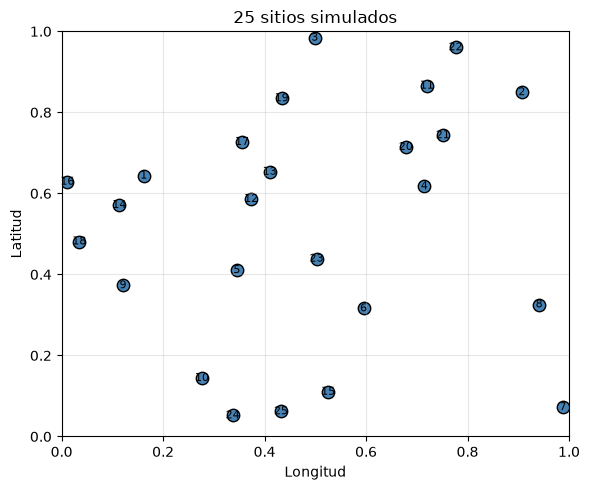

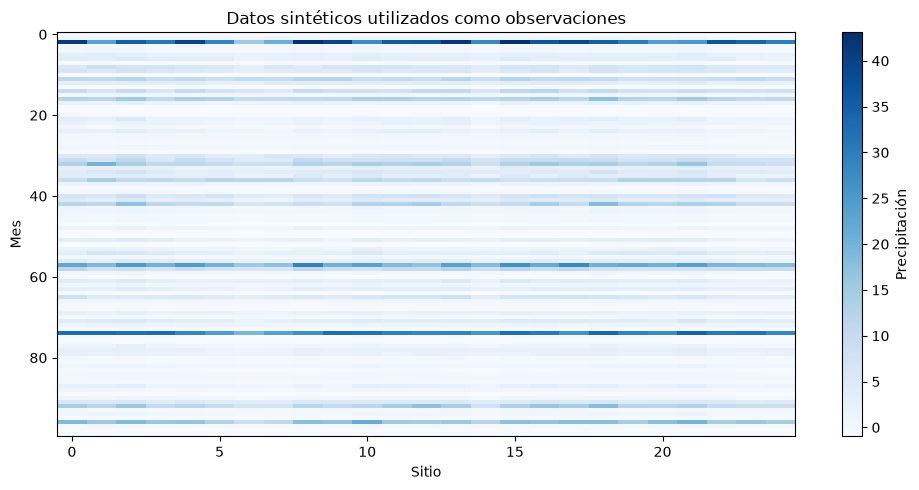

In [ ]:
# ============================================================
# PRUEBA COMPLETAMENTE SINTÉTICA DE RECUPERACIÓN
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.spatial.distance import pdist, squareform


# ============================================================
# 1. CONFIGURACIÓN DEL EXPERIMENTO
# ============================================================

m = 100
nsites = 25

seed_experimento = 20260831

rng = np.random.default_rng(seed_experimento)


# ============================================================
# 2. GENERAR 25 SITIOS UNIFORMEMENTE DISTRIBUIDOS EN [0,1]x[0,1]
# ============================================================

ubic = rng.uniform(
    low=0,
    high=1,
    size=(nsites, 2)
)

lon = ubic[:, 0]
lat = ubic[:, 1]

print("Número de sitios:", nsites)
print("Rango longitud:", lon.min(), lon.max())
print("Rango latitud:", lat.min(), lat.max())


# ============================================================
# 3. MATRIZ DE DISTANCIAS ESPACIALES
# ============================================================

dist_mat = squareform(
    pdist(
        np.column_stack([lon, lat])
    )
)

print("\nDimensión dist_mat:", dist_mat.shape)


# ============================================================
# 4. CREAR MATRIZ DE DISEÑO
# ============================================================
#
# Para mantenerlo independiente de GLM0, definimos nosotros
# los términos espaciales.
#
# Usaremos:
#
# 1
# lat
# lon
# lat^2
# lat*lon
# lon^2
#
# Es decir, 6 coeficientes gamma.
#
# Hay que construir la matriz con m observaciones por sitio.
# El orden será:
#
# sitio 1 -> meses 1,...,100
# sitio 2 -> meses 1,...,100
# ...
# sitio 25 -> meses 1,...,100
#
# que es precisamente el orden que espera:
#
# alpha_long.reshape(nsites, m).T


gamma_true = np.array([
    1.20,    # constante
    0.30,    # lat
   -0.20,    # lon
    0.15,    # lat^2
    0.10,    # lat*lon
   -0.10     # lon^2
])

ngammas = len(gamma_true)


# Crear matriz espacial de cada sitio
X_sitios = np.column_stack([
    np.ones(nsites),
    lat,
    lon,
    lat**2,
    lat * lon,
    lon**2
])


# Repetir cada sitio durante los m meses
design_mat = np.repeat(
    X_sitios,
    repeats=m,
    axis=0
)


print("\nDimensión design_mat:", design_mat.shape)
print("Número de gamma:", ngammas)


# ============================================================
# 5. DEFINIR LOS PARÁMETROS VERDADEROS
# ============================================================

delta_true = 0.80
beta3_true = 15.0
rho_true = 1.50


# Tu código define:
#
# rho_upper_range = 5 * max(dist_mat)

rho_upper_range = 5 * np.max(dist_mat)


print("\n============================================")
print("PARÁMETROS VERDADEROS")
print("============================================")

print("Gamma:")
for i, valor in enumerate(gamma_true):
    print(f"  gamma_{i+1}: {valor:.4f}")

print(f"\ndelta : {delta_true:.4f}")
print(f"beta3 : {beta3_true:.4f}")
print(f"rho   : {rho_true:.4f}")
print(f"rho_max: {rho_upper_range:.4f}")


# ============================================================
# 6. CONVERTIR PARÁMETROS FÍSICOS A ESCALA THETA
# ============================================================

theta_delta_true = norm.ppf(
    delta_true / 3
)

theta_beta3_true = norm.ppf(
    (beta3_true - 2) / (150 - 2)
)

theta_rho_true = norm.ppf(
    rho_true / rho_upper_range
)


theta_true = np.concatenate([
    gamma_true,
    [
        theta_delta_true,
        theta_beta3_true,
        theta_rho_true
    ]
])


print("\n============================================")
print("THETA VERDADERO")
print("============================================")

print(theta_true)


# ============================================================
# 7. GENERAR LOS DATOS SINTÉTICOS
# ============================================================

rng_datos = np.random.default_rng(12345)

Y_simulado = simular_precipitacion_v1(
    theta=theta_true,
    m=m,
    nsites=nsites,
    dist_mat=dist_mat,
    design_mat=design_mat,
    ngammas=ngammas,
    rho_upper_range=rho_upper_range,
    rng=rng_datos
)


print("\n============================================")
print("DATOS SIMULADOS")
print("============================================")

print("Dimensiones:", Y_simulado.shape)
print("Mínimo:", Y_simulado.min())
print("Máximo:", Y_simulado.max())
print("Media:", Y_simulado.mean())
print("Desv. estándar:", Y_simulado.std())

assert Y_simulado.shape == (m, nsites)
assert np.isfinite(Y_simulado).all()


# ============================================================
# 8. VISUALIZAR LOS SITIOS
# ============================================================

plt.figure(figsize=(6, 5))

plt.scatter(
    lon,
    lat,
    s=80,
    color="steelblue",
    edgecolor="black"
)

for i in range(nsites):
    plt.text(
        lon[i],
        lat[i],
        str(i + 1),
        fontsize=8,
        ha="center",
        va="center"
    )

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("25 sitios simulados")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 9. VISUALIZAR LOS DATOS SIMULADOS
# ============================================================

plt.figure(figsize=(10, 5))

plt.imshow(
    Y_simulado,
    aspect="auto",
    interpolation="none",
    cmap="Blues"
)

plt.colorbar(label="Precipitación")
plt.xlabel("Sitio")
plt.ylabel("Mes")
plt.title("Datos sintéticos utilizados como observaciones")

plt.tight_layout()
plt.show()


# ============================================================
# 10. EJECUTAR ABC-SMC
# ============================================================

resultado_abc = proceso_abc_smc(
    real=Y_simulado,
    m=m,
    nsites=nsites,
    dist_mat=dist_mat,
    design_mat=design_mat,

    # Como no tenemos GLM0 real, necesitamos proporcionar
    # un objeto que tenga .params.values y .params.index.
    #
    # Creamos un objeto mínimo compatible con tu función.
    GLM0=type(
        "GLM0_sintetico",
        (),
        {
            "params": pd.Series(
                np.zeros(ngammas),
                index=[
                    "const",
                    "lat",
                    "lon",
                    "lat2",
                    "lat_lon",
                    "lon2"
                ]
            )
        }
    )(),

    n_cores=1,
    n_epochs=8,
    n_simul=2000,
    n_min_next=500,
    n_min_final=500,
    seed=987654
)




RESULTADO ABC-SMC
            delta       beta3           rho   distancia          peso
count  561.000000  561.000000  5.610000e+02  561.000000  5.610000e+02
mean     2.625667   91.282644  2.819226e+00   35.401052  1.782531e-03
std      0.446130   47.415538  2.172408e+00    0.919344  4.298487e-03
min      0.595995    2.070265  2.828919e-09   29.979842  7.622022e-11
25%      2.432672   51.187993  4.098052e-01   34.996601  1.632313e-05
50%      2.810415  100.156948  2.823846e+00   35.613570  2.313933e-04
75%      2.958236  138.739585  5.112330e+00   36.068262  1.250763e-03
max      2.999999  149.999898  5.620379e+00   36.466300  4.532306e-02

RECUPERACIÓN DE PARÁMETROS
parametro  verdadero   media  mediana    q025     q975   error  error_relativo  dentro_95
    delta     0.8000  2.3248   2.4654  0.5960   2.9788  1.5248          1.9060       True
    beta3    15.0000 80.7691  82.7236 12.2541 145.0775 65.7691          4.3846       True
      rho     1.5000  2.9602   2.9261  0.1762   5.565

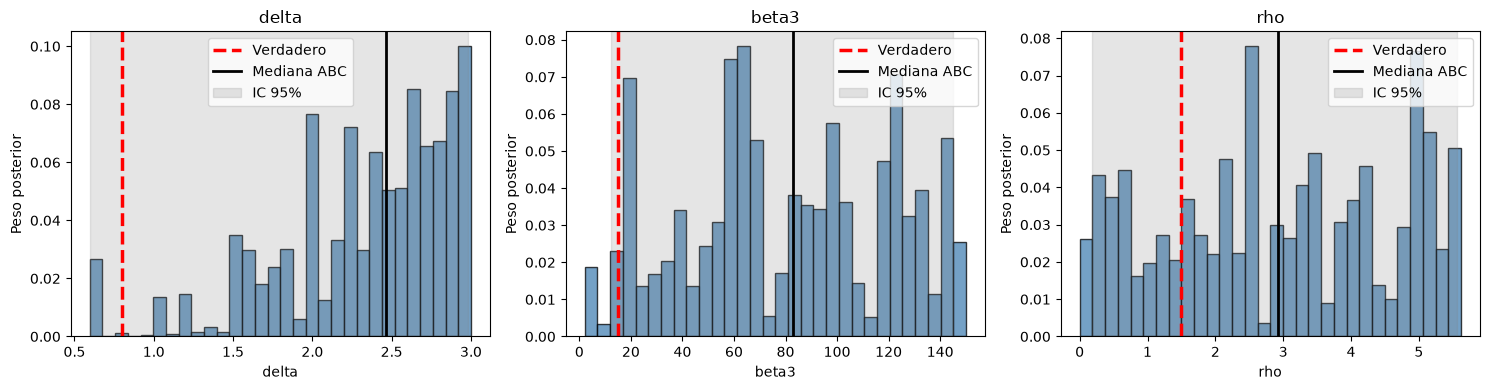

In [3]:

# ============================================================
# 11. RESULTADOS
# ============================================================

print("\n============================================")
print("RESULTADO ABC-SMC")
print("============================================")

print(
    resultado_abc[
        [
            "delta",
            "beta3",
            "rho",
            "distancia",
            "peso"
        ]
    ].describe()
)


# ============================================================
# 12. FUNCIÓN PARA RESUMEN POSTERIOR PONDERADO
# ============================================================

def resumen_ponderado(x, pesos):

    x = np.asarray(x)
    pesos = np.asarray(pesos)

    orden = np.argsort(x)

    x = x[orden]
    pesos = pesos[orden]

    pesos = pesos / pesos.sum()

    acumulado = np.cumsum(pesos)

    media = np.sum(x * pesos)

    mediana = x[np.searchsorted(acumulado, 0.50)]

    q025 = x[np.searchsorted(acumulado, 0.025)]
    q05 = x[np.searchsorted(acumulado, 0.05)]
    q95 = x[np.searchsorted(acumulado, 0.95)]
    q975 = x[np.searchsorted(acumulado, 0.975)]

    return {
        "media": media,
        "mediana": mediana,
        "q025": q025,
        "q05": q05,
        "q95": q95,
        "q975": q975
    }


# ============================================================
# 13. COMPARAR VERDADERO VS POSTERIOR
# ============================================================

parametros_true = {
    "delta": delta_true,
    "beta3": beta3_true,
    "rho": rho_true
}


filas = []

for parametro, verdadero in parametros_true.items():

    resumen = resumen_ponderado(
        resultado_abc[parametro].values,
        resultado_abc["peso"].values
    )

    filas.append({
        "parametro": parametro,
        "verdadero": verdadero,
        "media": resumen["media"],
        "mediana": resumen["mediana"],
        "q025": resumen["q025"],
        "q975": resumen["q975"],
        "error": resumen["media"] - verdadero,
        "error_relativo": (
            (resumen["media"] - verdadero) / verdadero
        ),
        "dentro_95": (
            verdadero >= resumen["q025"]
            and
            verdadero <= resumen["q975"]
        )
    })


tabla_recuperacion = pd.DataFrame(filas)


print("\n============================================")
print("RECUPERACIÓN DE PARÁMETROS")
print("============================================")

print(
    tabla_recuperacion.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 14. RECUPERACIÓN DE LOS GAMMA
# ============================================================

filas_gamma = []

for i, nombre in enumerate([
    "const",
    "lat",
    "lon",
    "lat2",
    "lat_lon",
    "lon2"
]):

    columna = f"gamma_{nombre}"

    resumen = resumen_ponderado(
        resultado_abc[columna].values,
        resultado_abc["peso"].values
    )

    verdadero = gamma_true[i]

    filas_gamma.append({
        "parametro": columna,
        "verdadero": verdadero,
        "media": resumen["media"],
        "mediana": resumen["mediana"],
        "q025": resumen["q025"],
        "q975": resumen["q975"],
        "error": resumen["media"] - verdadero
    })


tabla_gamma = pd.DataFrame(filas_gamma)


print("\n============================================")
print("RECUPERACIÓN DE GAMMA")
print("============================================")

print(
    tabla_gamma.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 15. GRÁFICAS DE LOS PARÁMETROS
# ============================================================

parametros_graficar = [
    ("delta", delta_true),
    ("beta3", beta3_true),
    ("rho", rho_true)
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)


for ax, (parametro, verdadero) in zip(
    axes,
    parametros_graficar
):

    x = resultado_abc[parametro].values
    pesos = resultado_abc["peso"].values

    ax.hist(
        x,
        bins=30,
        weights=pesos,
        color="steelblue",
        edgecolor="black",
        alpha=0.75
    )

    resumen = resumen_ponderado(x, pesos)

    ax.axvline(
        verdadero,
        color="red",
        linestyle="--",
        linewidth=2.5,
        label="Verdadero"
    )

    ax.axvline(
        resumen["mediana"],
        color="black",
        linestyle="-",
        linewidth=2,
        label="Mediana ABC"
    )

    ax.axvspan(
        resumen["q025"],
        resumen["q975"],
        color="gray",
        alpha=0.20,
        label="IC 95%"
    )

    ax.set_title(parametro)
    ax.set_xlabel(parametro)
    ax.set_ylabel("Peso posterior")
    ax.legend()


plt.tight_layout()
plt.show()
